id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


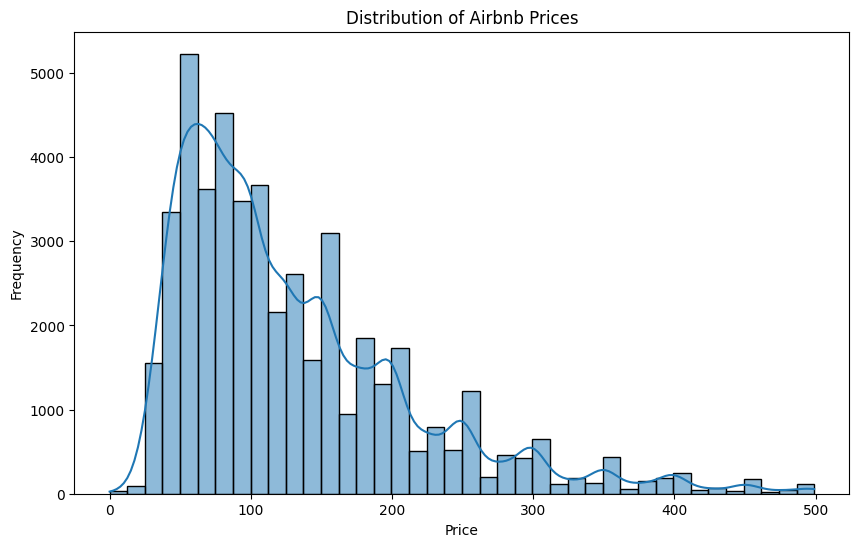

C:\Users\sdadd\AppData\Local\Temp\ipykernel_23868\2526041636.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_airbnb, x='neighbourhood_group', palette='viridis')


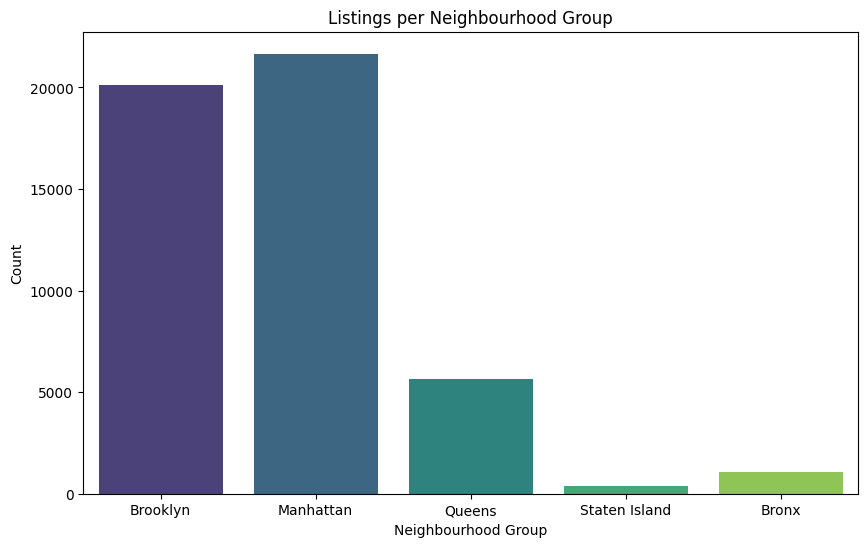

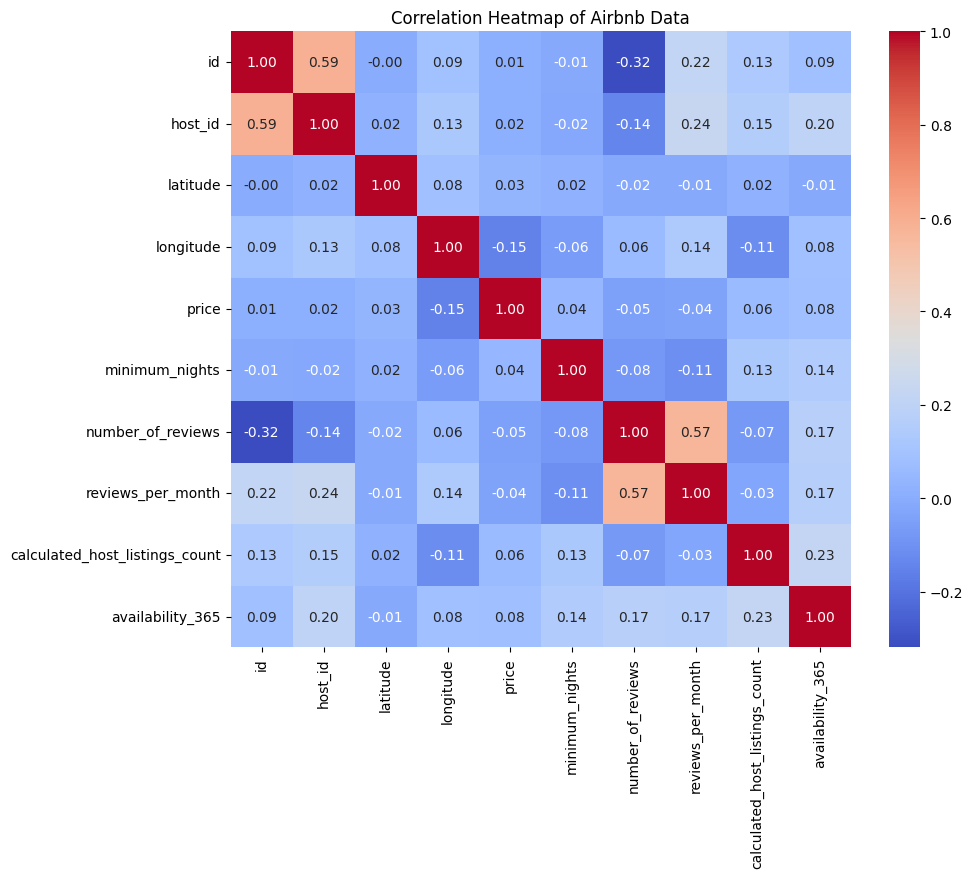

In [3]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cell 2: Load Data
# Ensure 'AB_NYC_2019.csv' is in the same folder as your notebook
df_airbnb = pd.read_csv('AB_NYC_2019.csv')

# Cell 3: Data Cleaning (Strictly following the slide: Mean, Median, Mode)

# 1. Fill missing numerical values using the MEDIAN
df_airbnb['reviews_per_month'] = df_airbnb['reviews_per_month'].fillna(df_airbnb['reviews_per_month'].median())

# 2. Fill missing text/categorical values using the MODE (index 0 gets the most frequent one)
df_airbnb['name'] = df_airbnb['name'].fillna(df_airbnb['name'].mode()[0])
df_airbnb['host_name'] = df_airbnb['host_name'].fillna(df_airbnb['host_name'].mode()[0])

# Check if data is clean
print(df_airbnb.isnull().sum())

# Cell 4: Visualisation 1 - Histogram (Distribution)
plt.figure(figsize=(10, 6))
# Using a histogram to check the distribution of prices under $500 to avoid extreme outliers
sns.histplot(df_airbnb[df_airbnb['price'] < 500]['price'], bins=40, kde=True)
plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Cell 5: Visualisation 2 - Countplot (Categorical Distribution)
plt.figure(figsize=(10, 6))
# Countplot to see the distribution of listings across different neighbourhood groups
sns.countplot(data=df_airbnb, x='neighbourhood_group', palette='viridis')
plt.title('Listings per Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Count')
plt.show()

# Cell 6: Visualisation 3 - The Correlation Heatmap (Summary Statistics)
plt.figure(figsize=(10, 8))
# This creates the colored boxes with correlation numbers (-1 to 1)
correlation_matrix = df_airbnb.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Airbnb Data')
plt.show()